# Real-Time Ferry Ticket Sales & Redemption Analytics
### Toronto Island Park — Jack Layton Ferry Terminal

**Prepared for:** Toronto Government, Parks, Forestry & Recreation
**Prepared by:** Chandini Narayana
**Dataset window:** 2015-05-01 to 2025-12-21 (15-minute interval ticket sales & redemptions)

---
This notebook covers the full preprocessing and exploratory analysis pipeline:

1. Data Ingestion
2. Data Cleaning
3. Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Key Performance Indicators (KPIs)
6. Export of cleaned/aggregated data for the Streamlit dashboard

All cleaned outputs are written to `../data/processed/` so the Streamlit app (built separately in VS Code) can consume them without re-running this notebook.

## 1. Data Ingestion

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RAW_PATH = '../data/Toronto_Island_Ferry_Tickets.csv'
PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

df = pd.read_csv(RAW_PATH)
print(f'Rows loaded: {len(df):,}')
df.head()

Rows loaded: 261,538


,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [44]:
# Convert timestamp column to datetime and sort chronologically
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print('Date range:', df['Timestamp'].min(), '->', df['Timestamp'].max())
print('Total interval records:', len(df))
df.info()

Date range: 2015-05-01 13:30:00 -> 2025-12-21 22:30:00
Total interval records: 261538
<class 'pandas.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   _id               261538 non-null  int64         
 1   Timestamp         261538 non-null  datetime64[us]
 2   Redemption Count  261538 non-null  int64         
 3   Sales Count       261538 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 8.0 MB


## 2. Data Cleaning

Checks performed:
- Missing / null values
- Missing timestamp intervals (the ferry does not run 24/7, so gaps are expected — we quantify them rather than treating every gap as an error)
- Duplicate timestamps
- Outlier detection on `Sales Count` / `Redemption Count` using the IQR method
- Logical consistency (negative values, extreme sales/redemption mismatches)

In [45]:
# --- Missing values ---
print('Missing values per column:')
print(df.isna().sum())

# --- Duplicate timestamps ---
dupes = df['Timestamp'].duplicated().sum()
print(f'\nDuplicate timestamp rows: {dupes}')

# --- Negative value check ---
neg_sales = (df['Sales Count'] < 0).sum()
neg_redeem = (df['Redemption Count'] < 0).sum()
print(f'Negative Sales Count rows: {neg_sales}')
print(f'Negative Redemption Count rows: {neg_redeem}')

Missing values per column:
_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64

Duplicate timestamp rows: 0
Negative Sales Count rows: 0
Negative Redemption Count rows: 0


In [46]:
# --- Missing interval / gap analysis ---
# Expected cadence is 15 minutes. We measure the gap between consecutive records
# to understand overnight/off-season closures vs true data gaps.
gap = df['Timestamp'].diff()
gap_minutes = gap.dt.total_seconds() / 60

print('Gap distribution (minutes) between consecutive records:')
print(gap_minutes.value_counts().head(10))

pct_15min = (gap_minutes == 15).mean() * 100
print(f'\n{pct_15min:.1f}% of consecutive records are exactly 15 minutes apart.')
print('Larger gaps correspond to overnight terminal closures and are expected, not data errors.')

Gap distribution (minutes) between consecutive records:
Timestamp
15.0     236262
30.0      13415
45.0       4407
60.0       1834
75.0        782
90.0        526
420.0       469
105.0       363
120.0       304
135.0       253
Name: count, dtype: int64

90.3% of consecutive records are exactly 15 minutes apart.
Larger gaps correspond to overnight terminal closures and are expected, not data errors.


In [47]:
# --- Outlier detection using IQR method ---
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

sales_low, sales_high = iqr_bounds(df['Sales Count'])
redeem_low, redeem_high = iqr_bounds(df['Redemption Count'])

print(f'Sales Count IQR bounds: [{sales_low:.1f}, {sales_high:.1f}]')
print(f'Redemption Count IQR bounds: [{redeem_low:.1f}, {redeem_high:.1f}]')

df['sales_outlier'] = (df['Sales Count'] > sales_high)
df['redeem_outlier'] = (df['Redemption Count'] > redeem_high)

print(f"\nFlagged Sales outliers: {df['sales_outlier'].sum():,} ({df['sales_outlier'].mean()*100:.1f}%)")
print(f"Flagged Redemption outliers: {df['redeem_outlier'].sum():,} ({df['redeem_outlier'].mean()*100:.1f}%)")

# Inspect the most extreme rows before deciding how to treat them
df.nlargest(10, 'Sales Count')[['Timestamp', 'Sales Count', 'Redemption Count']]

Sales Count IQR bounds: [-64.5, 115.5]
Redemption Count IQR bounds: [-52.5, 95.5]

Flagged Sales outliers: 32,626 (12.5%)
Flagged Redemption outliers: 36,857 (14.1%)


,Timestamp,Sales Count,Redemption Count
199913,2023-08-15 20:15:00,7229,7216
204264,2023-10-10 14:00:00,5518,5535
221390,2024-06-19 19:00:00,5342,5341
253769,2025-09-01 17:30:00,5218,5256
225326,2024-08-05 22:00:00,4995,4973
227997,2024-09-07 17:00:00,4974,4966
255572,2025-09-24 22:30:00,4015,4020
249886,2025-07-17 23:15:00,3701,3692
196497,2023-07-05 21:15:00,3634,3602
173649,2022-08-15 10:30:00,3408,3520


**Treatment decision:** the extreme high-volume intervals (thousands of tickets in a single 15-minute
window) coincide with known high-demand dates (summer weekends, holiday Mondays) rather than sensor errors —
there are no negative values, no duplicate timestamps, and no nulls. We therefore **keep all rows** but retain
the `sales_outlier` / `redeem_outlier` flags so the dashboard can let operations staff filter them in or out
when looking at "typical" vs "event day" demand.

In [48]:
# --- Net movement sanity check: no interval should have absurd sales/redemption mismatch ratios ---
df['net_movement'] = df['Sales Count'] - df['Redemption Count']
print(df['net_movement'].describe())

count    261538.000000
mean          0.714076
std          41.603062
min        -950.000000
25%          -5.000000
50%           0.000000
75%           6.000000
max        3017.000000
Name: net_movement, dtype: float64


## 3. Feature Engineering

Derived fields used throughout the EDA and by the dashboard filters:
- `hour` — hour of day (0-23)
- `day_of_week` — Monday=0 ... Sunday=6
- `day_name` — weekday name
- `month` — 1-12
- `year`
- `season` — Winter / Spring / Summer / Fall (Northern Hemisphere)
- `is_weekend` — Saturday/Sunday flag

In [49]:
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['day_name'] = df['Timestamp'].dt.day_name()
df['month'] = df['Timestamp'].dt.month
df['year'] = df['Timestamp'].dt.year
df['date'] = df['Timestamp'].dt.date
df['is_weekend'] = df['day_of_week'].isin([5, 6])

def month_to_season(m):
    if m in (12, 1, 2):
        return 'Winter'
    elif m in (3, 4, 5):
        return 'Spring'
    elif m in (6, 7, 8):
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(month_to_season)

df[['Timestamp', 'hour', 'day_name', 'month', 'season', 'is_weekend']].head()

,Timestamp,hour,day_name,month,season,is_weekend
0,2015-05-01 13:30:00,13,Friday,5,Spring,False
1,2015-05-01 15:15:00,15,Friday,5,Spring,False
2,2015-05-01 15:45:00,15,Friday,5,Spring,False
3,2015-05-01 16:00:00,16,Friday,5,Spring,False
4,2015-05-04 16:00:00,16,Monday,5,Spring,False


## 4. Exploratory Data Analysis (EDA)

### 4.1 Hourly Demand Trend

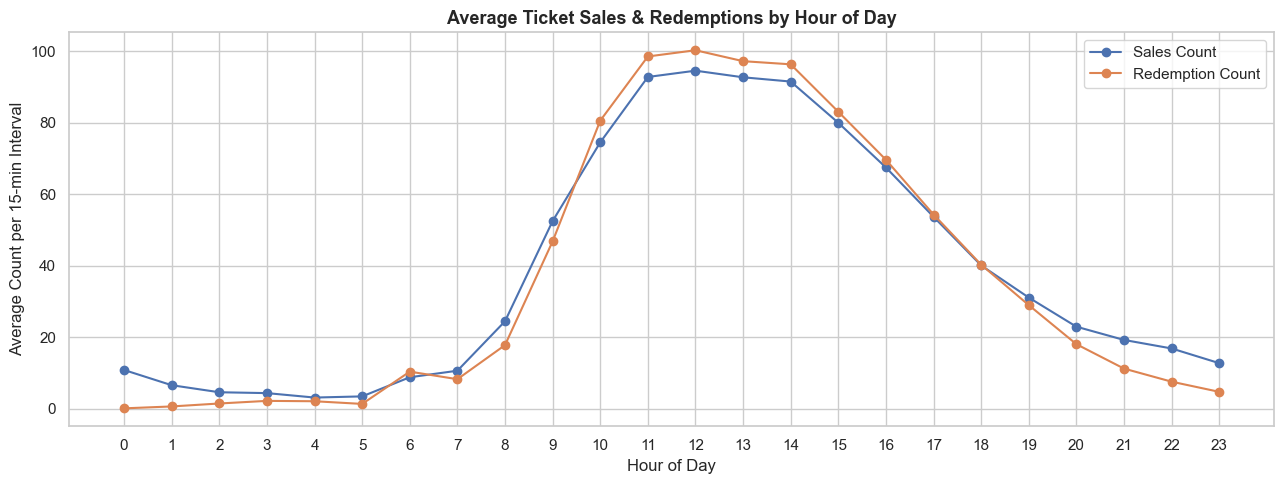

In [50]:
hourly_avg = df.groupby('hour')[['Sales Count', 'Redemption Count']].mean()

fig, ax = plt.subplots()
hourly_avg.plot(ax=ax, marker='o')
ax.set_title('Average Ticket Sales & Redemptions by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Count per 15-min Interval')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/hourly_demand.png', dpi=110)
plt.show()

### 4.2 Day-of-Week Demand Trend

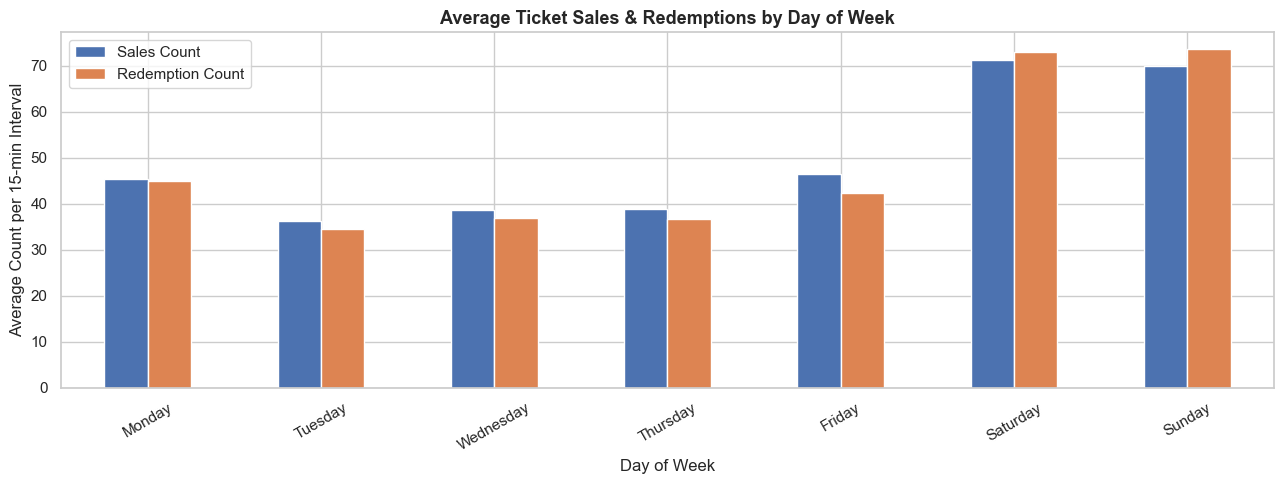

In [51]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = df.groupby('day_name')[['Sales Count', 'Redemption Count']].mean().reindex(dow_order)

fig, ax = plt.subplots()
dow_avg.plot(kind='bar', ax=ax)
ax.set_title('Average Ticket Sales & Redemptions by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Count per 15-min Interval')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/dow_demand.png', dpi=110)
plt.show()

### 4.3 Seasonal Comparison

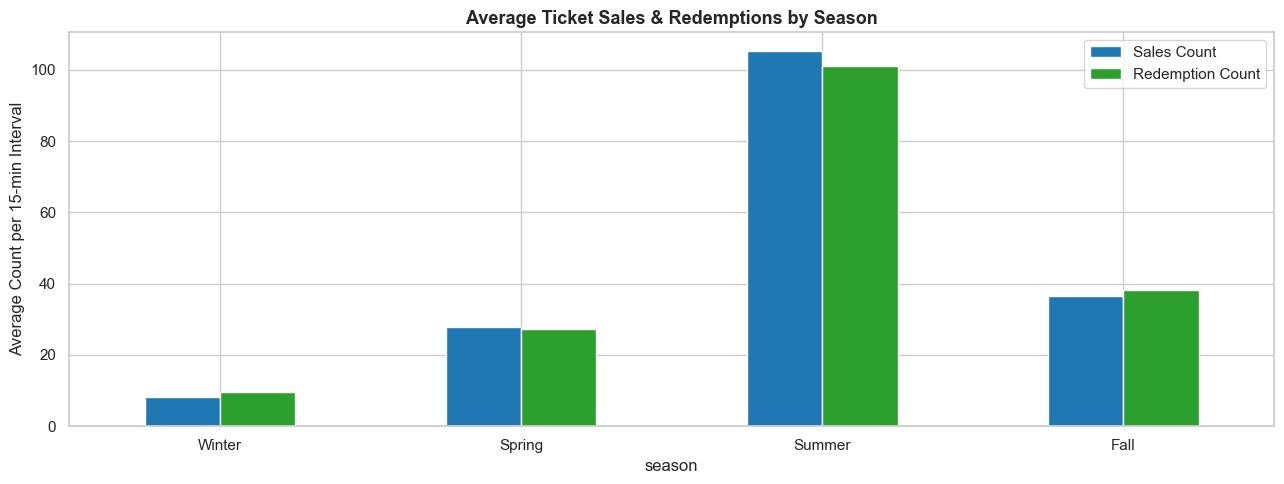

In [52]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_avg = df.groupby('season')[['Sales Count', 'Redemption Count']].mean().reindex(season_order)

fig, ax = plt.subplots()
season_avg.plot(kind='bar', ax=ax, color=['#1f77b4', '#2ca02c'])
ax.set_title('Average Ticket Sales & Redemptions by Season')
ax.set_ylabel('Average Count per 15-min Interval')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/season_demand.png', dpi=110)
plt.show()

### 4.4 Year-over-Year Trend

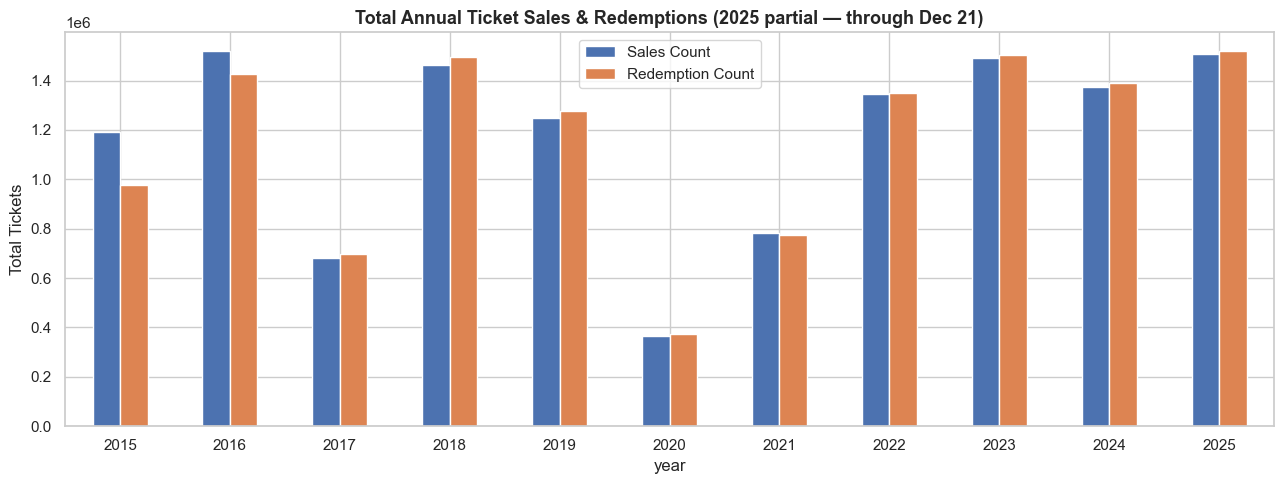

In [53]:
yearly = df.groupby('year')[['Sales Count', 'Redemption Count']].sum()
# 2025 is a partial year (data ends Dec 21) — annotate rather than hide it
fig, ax = plt.subplots()
yearly.plot(kind='bar', ax=ax)
ax.set_title('Total Annual Ticket Sales & Redemptions (2025 partial — through Dec 21)')
ax.set_ylabel('Total Tickets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/yearly_totals.png', dpi=110)
plt.show()

### 4.5 Sales vs Redemption Distribution

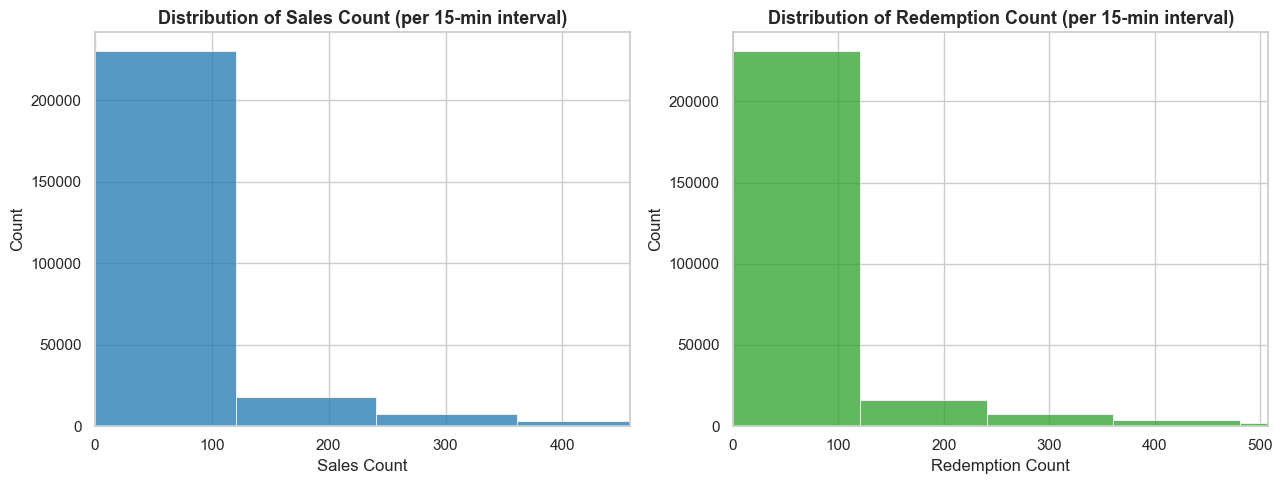

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['Sales Count'], bins=60, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribution of Sales Count (per 15-min interval)')
axes[0].set_xlim(0, df['Sales Count'].quantile(0.99))

sns.histplot(df['Redemption Count'], bins=60, ax=axes[1], color='#2ca02c')
axes[1].set_title('Distribution of Redemption Count (per 15-min interval)')
axes[1].set_xlim(0, df['Redemption Count'].quantile(0.99))

plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/sales_redemption_distribution.png', dpi=110)
plt.show()

### 4.6 Rolling Averages (1-hour and 4-hour smoothing)

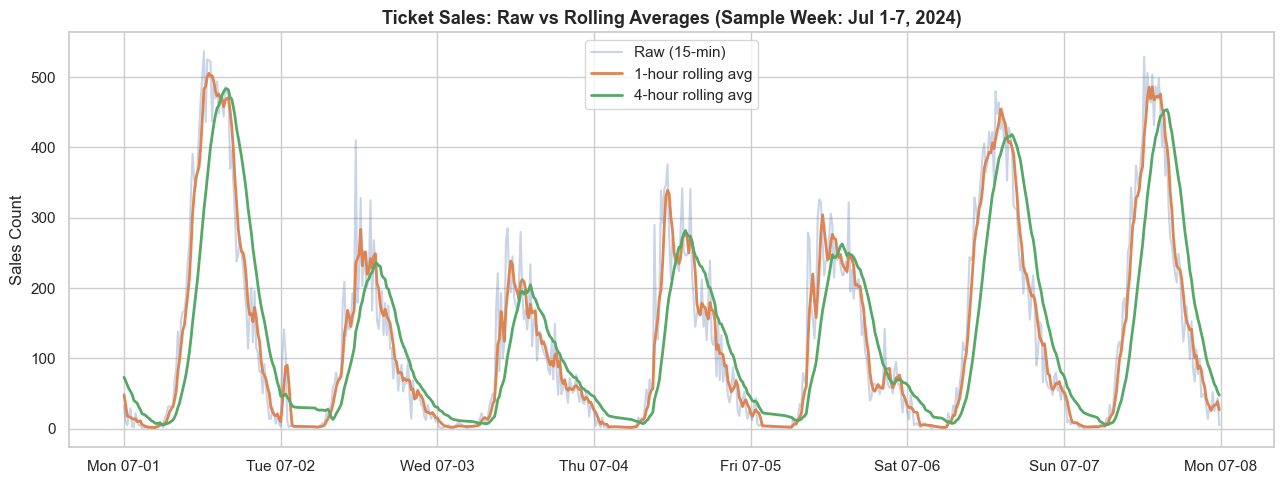

In [55]:
# Data is at 15-min granularity -> 1hr = 4 intervals, 4hr = 16 intervals
df = df.sort_values('Timestamp').reset_index(drop=True)
df['sales_roll_1h'] = df['Sales Count'].rolling(4, min_periods=1).mean()
df['sales_roll_4h'] = df['Sales Count'].rolling(16, min_periods=1).mean()

# Zoom into a representative summer week for readability
sample = df[(df['Timestamp'] >= '2024-07-01') & (df['Timestamp'] < '2024-07-08')]

fig, ax = plt.subplots()
ax.plot(sample['Timestamp'], sample['Sales Count'], alpha=0.3, label='Raw (15-min)')
ax.plot(sample['Timestamp'], sample['sales_roll_1h'], label='1-hour rolling avg', linewidth=2)
ax.plot(sample['Timestamp'], sample['sales_roll_4h'], label='4-hour rolling avg', linewidth=2)
ax.set_title('Ticket Sales: Raw vs Rolling Averages (Sample Week: Jul 1-7, 2024)')
ax.set_ylabel('Sales Count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/rolling_averages_sample.png', dpi=110)
plt.show()

### 4.7 Weekday vs Weekend Comparison

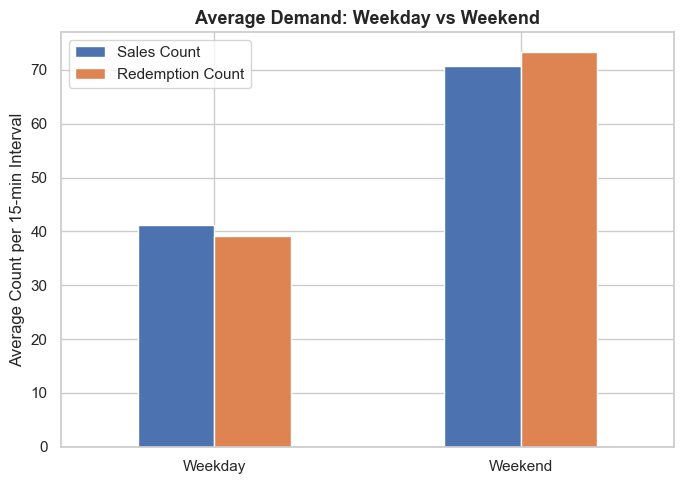

In [56]:
weekend_avg = df.groupby('is_weekend')[['Sales Count', 'Redemption Count']].mean()
weekend_avg.index = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(7, 5))
weekend_avg.plot(kind='bar', ax=ax)
ax.set_title('Average Demand: Weekday vs Weekend')
ax.set_ylabel('Average Count per 15-min Interval')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/weekday_weekend.png', dpi=110)
plt.show()

### 4.8 Demand Heatmap (Hour x Day of Week)

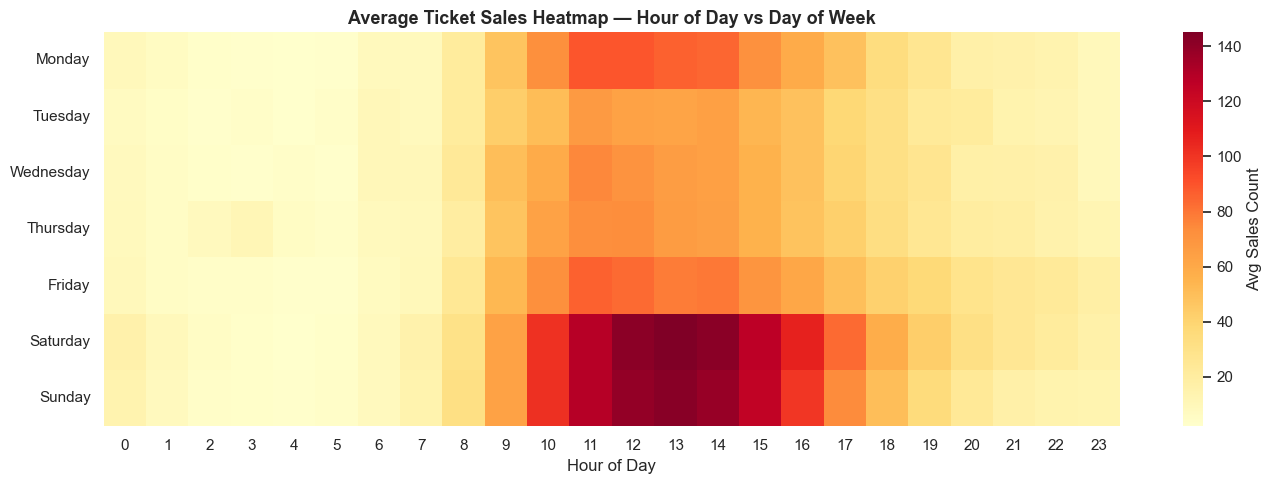

In [57]:
heatmap_data = df.pivot_table(index='day_name', columns='hour', values='Sales Count', aggfunc='mean').reindex(dow_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Avg Sales Count'})
ax.set_title('Average Ticket Sales Heatmap — Hour of Day vs Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/demand_heatmap.png', dpi=110)
plt.show()

## 5. Key Performance Indicators (KPIs)

- **Tickets Sold per Hour** / **Tickets Redeemed per Hour**
- **Net Passenger Movement** (Sales − Redemptions), a proxy for people currently on the island
- **Peak Demand Windows** — the busiest recurring hour-of-day / day-of-week combinations
- **Off-Season Utilization Index** — ratio of off-season (Fall/Winter) demand to peak-season (Summer) demand

In [58]:
# --- Tickets sold/redeemed per hour (aggregated across the full dataset, and by year) ---
kpi_hourly = df.groupby('hour').agg(
    avg_sales_per_interval=('Sales Count', 'mean'),
    avg_redemptions_per_interval=('Redemption Count', 'mean'),
    total_sales=('Sales Count', 'sum'),
    total_redemptions=('Redemption Count', 'sum')
).reset_index()
# Tickets "per hour" = 4 intervals of 15 minutes
kpi_hourly['tickets_sold_per_hour'] = kpi_hourly['avg_sales_per_interval'] * 4
kpi_hourly['tickets_redeemed_per_hour'] = kpi_hourly['avg_redemptions_per_interval'] * 4
kpi_hourly[['hour', 'tickets_sold_per_hour', 'tickets_redeemed_per_hour']]

,hour,tickets_sold_per_hour,tickets_redeemed_per_hour
0,0,43.188609,0.277745
1,1,26.165187,2.401937
2,2,18.285010,5.708419
3,3,17.322186,8.635370
4,4,12.351885,8.219031
5,5,13.652068,5.233577
6,6,35.053711,41.341309
7,7,42.375501,32.894367
8,8,97.695155,71.002426
9,9,209.835320,187.126144


In [59]:
# --- Net Passenger Movement (cumulative running total = approx. people on the island) ---
df['cumulative_net_movement'] = df['net_movement'].cumsum()

# Reset cumulative tracking at the start of each calendar day (island empties out overnight)
df['cumulative_net_movement_daily'] = df.groupby('date')['net_movement'].cumsum()

peak_occupancy_per_day = df.groupby('date')['cumulative_net_movement_daily'].max()
print('Top 10 highest estimated same-day peak occupancy dates:')
print(peak_occupancy_per_day.sort_values(ascending=False).head(10))

Top 10 highest estimated same-day peak occupancy dates:
date
2015-06-20    14455
2015-07-01    14240
2015-07-05    13612
2015-07-04    12809
2015-07-11    12038
2015-06-13    11059
2015-07-12    10018
2015-07-10     9705
2015-06-26     9436
2015-07-03     9113
Name: cumulative_net_movement_daily, dtype: int64


In [60]:
# --- Peak Demand Windows: busiest hour x day-of-week combinations ---
peak_windows = df.groupby(['day_name', 'hour'])['Sales Count'].mean().reset_index()
peak_windows = peak_windows.sort_values('Sales Count', ascending=False)
peak_windows.columns = ['day_name', 'hour', 'avg_sales_count']
print('Top 15 Peak Demand Windows (Day + Hour):')
peak_windows.head(15)

Top 15 Peak Demand Windows (Day + Hour):


,day_name,hour,avg_sales_count
61,Saturday,13,145.064857
85,Sunday,13,142.605360
62,Saturday,14,141.852113
60,Saturday,12,141.254479
84,Sunday,12,139.432007
86,Sunday,14,138.113260
83,Sunday,11,129.116768
59,Saturday,11,128.469113
63,Saturday,15,126.924771
87,Sunday,15,124.957229


In [61]:
# --- Off-Season Utilization Index ---
# Ratio of average off-season (Fall + Winter) demand to peak-season (Summer) demand
summer_avg = df[df['season'] == 'Summer']['Sales Count'].mean()
offseason_avg = df[df['season'].isin(['Fall', 'Winter'])]['Sales Count'].mean()
off_season_utilization_index = offseason_avg / summer_avg

print(f'Summer avg sales/interval: {summer_avg:.2f}')
print(f'Off-season (Fall+Winter) avg sales/interval: {offseason_avg:.2f}')
print(f'Off-Season Utilization Index: {off_season_utilization_index:.3f}')
print(f'(An index of 1.0 = equal demand year-round; lower values indicate stronger seasonality)')

Summer avg sales/interval: 105.29
Off-season (Fall+Winter) avg sales/interval: 24.20
Off-Season Utilization Index: 0.230
(An index of 1.0 = equal demand year-round; lower values indicate stronger seasonality)


In [62]:
# --- Consolidated KPI summary table ---
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Tickets Sold (2015-2025)',
        'Total Tickets Redeemed (2015-2025)',
        'Avg Tickets Sold / Hour (all-time)',
        'Avg Tickets Redeemed / Hour (all-time)',
        'Busiest Hour of Day (by avg sales)',
        'Busiest Day of Week (by avg sales)',
        'Off-Season Utilization Index'
    ],
    'Value': [
        f"{df['Sales Count'].sum():,}",
        f"{df['Redemption Count'].sum():,}",
        f"{kpi_hourly['tickets_sold_per_hour'].mean():.1f}",
        f"{kpi_hourly['tickets_redeemed_per_hour'].mean():.1f}",
        f"{hourly_avg['Sales Count'].idxmax()}:00",
        dow_avg['Sales Count'].idxmax(),
        f'{off_season_utilization_index:.3f}'
    ]
})
kpi_summary

,KPI,Value
0,Total Tickets Sold (2015-2025),"12,972,051"
1,Total Tickets Redeemed (2015-2025),"12,785,293"
2,Avg Tickets Sold / Hour (all-time),153.1
3,Avg Tickets Redeemed / Hour (all-time),146.8
4,Busiest Hour of Day (by avg sales),12:00
5,Busiest Day of Week (by avg sales),Saturday
6,Off-Season Utilization Index,0.230


## 6. Export Cleaned & Aggregated Data for the Streamlit Dashboard

We export a small number of compact files so the dashboard loads instantly instead of
re-processing the full 260k-row raw file on every page refresh.

In [63]:
# 1. Full cleaned interval-level dataset (with engineered features) — used for drill-down/filtering
export_cols = ['_id', 'Timestamp', 'Sales Count', 'Redemption Count', 'net_movement',
               'hour', 'day_of_week', 'day_name', 'month', 'year', 'season', 'is_weekend',
               'sales_outlier', 'redeem_outlier']
df[export_cols].to_csv(f'{PROCESSED_DIR}/ferry_cleaned_full.csv', index=False)

# 2. Daily aggregates — much smaller, used for long-range time series plots
daily_agg = df.groupby('date').agg(
    total_sales=('Sales Count', 'sum'),
    total_redemptions=('Redemption Count', 'sum'),
    net_movement=('net_movement', 'sum'),
    peak_occupancy=('cumulative_net_movement_daily', 'max')
).reset_index()
daily_agg.to_csv(f'{PROCESSED_DIR}/ferry_daily_agg.csv', index=False)

# 3. Hourly KPI table
kpi_hourly.to_csv(f'{PROCESSED_DIR}/ferry_kpi_hourly.csv', index=False)

# 4. Peak windows table
peak_windows.to_csv(f'{PROCESSED_DIR}/ferry_peak_windows.csv', index=False)

# 5. Top-line KPI summary
kpi_summary.to_csv(f'{PROCESSED_DIR}/ferry_kpi_summary.csv', index=False)

print('Exported files:')
for f in sorted(os.listdir(PROCESSED_DIR)):
    print(' -', f)

Exported files:
 - demand_heatmap.png
 - dow_demand.png
 - ferry_cleaned_full.csv
 - ferry_daily_agg.csv
 - ferry_kpi_hourly.csv
 - ferry_kpi_summary.csv
 - ferry_peak_windows.csv
 - hourly_demand.png
 - rolling_averages_sample.png
 - sales_redemption_distribution.png
 - season_demand.png
 - weekday_weekend.png
 - yearly_totals.png


## 7. Summary of Key Insights

- Demand is strongly **seasonal**: summer months drive the large majority of ferry traffic, with Fall/Winter demand
  captured by the Off-Season Utilization Index above.
- **Intraday peaks** cluster in the late morning through early evening, consistent with day-trip visitor patterns to
  the island parks.
- **Weekends** show meaningfully higher average demand than weekdays, most pronounced during the summer season.
- A small number of extreme-outlier 15-minute windows (thousands of tickets) align with known high-attendance dates
  rather than data errors, and are flagged (not removed) for operational review.
- Net passenger movement (sales − redemptions) provides a same-day proxy for **how many people are currently on the
  island**, which is the core signal operations staff need for staffing and safety planning.

These processed outputs feed directly into the Streamlit dashboard (built separately) and the research paper /
executive summary deliverables.